In [1]:
import sqlite3
import pandas as pd

In [2]:
churn_conn = sqlite3.connect("ecommerce_churn.db")
churn_cursor = churn_conn.cursor()

In [3]:
churn_cursor.execute(''' 
CREATE TABLE IF NOT EXISTS customer_churn (
customer_id INTIGER PRIMARY KEY,
customer_name TEXT,
age INTEGER,
tenure_months INTEGER,
total_spend REAL,
churn_status TEXT
)
''')

In [4]:
cust_data = [
    (101, 'Ananya Sharma', 28, 12, 15400.50, 'Active'),
    (102, 'Rahul Patil', 35, 3, 2100.00, 'Churned'),
    (103, 'Priya Nair', 42, 24, 45000.00, 'Active'),
    (104, 'Amit Deshmukh', 22, 1, 500.00, 'Churned'),
    (105, 'Sneha Kulkarni', 31, 18, 29300.20, 'Active'),
    (106, 'Vikram Singh', 45, 5, 3400.00, 'Churned'),
    (107, 'Megha Joshi', 29, 14, 18200.00, 'Active'),
    (108, 'Rohan Das', 38, 2, 1200.50, 'Churned'),
    (109,'Bhagyashri Gaikwad',28,12,14000.50,'Active'),
    (110,'Ravi Gaikwad',32,10,13000.50,'Active'),
    (111,'Swami Naik',24,8,10000.50,'Active'),
    (112,'Rohan Gaikwad',28,12,15000,'Active'),
    (113,'Suvarna Bote',29,15,12000.50,'Active'),
    (114,'Navin Sarote',30,11,16000,'Active'),
    (115,'Ashish Pokle',38,15,20000.50,'Active')
]

In [5]:
churn_cursor.executemany('INSERT OR IGNORE INTO customer_churn VALUES (?,?,?,?,?,?)', cust_data)
churn_conn.commit()

In [6]:
df= pd.read_sql("SELECT * FROM customer_churn",churn_conn)

In [7]:
df

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,102,Rahul Patil,35,3,2100.0,Churned
2,103,Priya Nair,42,24,45000.0,Active
3,104,Amit Deshmukh,22,1,500.0,Churned
4,105,Sneha Kulkarni,31,18,29300.2,Active
5,106,Vikram Singh,45,5,3400.0,Churned
6,107,Megha Joshi,29,14,18200.0,Active
7,108,Rohan Das,38,2,1200.5,Churned
8,109,Bhagyashri Gaikwad,28,12,14000.5,Active
9,110,Ravi Gaikwad,32,10,13000.5,Active


In [8]:
#"Hi Bhagyashri, I need to look at the profile of the customers we are losing. Please write a query to find the Average Age and Average Total Spend of all the customers whose churn_status is 'Churned'."

In [9]:
status = "SELECT AVG(age), AVG(total_spend) FROM customer_churn WHERE churn_status = 'Churned'"

In [10]:
result = pd.read_sql(status, churn_conn)

In [11]:
result

,AVG(age),AVG(total_spend)
0,35.0,1800.125


In [12]:
#Task 2 "Hi Bhagyashri, great job on the first analysis! Now, to compare the data, please write a query to find the Average Age and Average Total Spend of all the customers whose churn_status is 'Active'. Let's see how our loyal customers behave!"

In [13]:
active_status = "SELECT AVG(age), AVG(total_spend) FROM customer_churn WHERE churn_status = 'Active'"

In [14]:
task2result = pd.read_sql(active_status,churn_conn)

In [15]:
task2result

,AVG(age),AVG(total_spend)
0,30.818182,18900.290909


In [16]:
# Task3"Hi Bhagyashri, you are doing great! Let's look at one more important metric. Please write a query to find the Average Tenure Months (AVG(tenure_months)) of the customers who have 'Churned'. I want to know exactly how many months they stay with us before leaving."

In [17]:
avgtenure = "SELECT AVG(tenure_months) FROM customer_churn WHERE churn_status ='Churned'"

In [18]:
task3result = pd.read_sql(avgtenure,churn_conn)

In [19]:
task3result

,AVG(tenure_months)
0,2.75


In [20]:
# Task4"Hi Bhagyashri, the insights are clear! Now, I want to present this data to the director. Please write the query for 'Churned' customers again, but this time use the 'AS' keyword to rename 'AVG(age)' to 'Average_Age' and 'AVG(total_spend)' to 'Average_Spend'. Make the output look clean and professional!"

In [21]:
rename = "SELECT AVG(age) AS 'Average_Age', AVG(total_spend) AS 'Average_Spend' FROM customer_churn WHERE churn_status ='Churned'"

In [22]:
task4result = pd.read_sql(rename, churn_conn)

In [23]:
task4result

,Average_Age,Average_Spend
0,35.0,1800.125


In [24]:
#Task5 "Hi Bhagyashri, excellent presentation with the aliases! Now, the director wants a quick summary count. Please write a query to find the total number of customers in each group. Use COUNT(*) and GROUP BY churn_status, and rename the count column to 'Total_Customers'. This will give us the exact breakdown!"

In [25]:
total = "SELECT churn_status, COUNT(*) AS total_customer FROM customer_churn GROUP BY churn_status"

In [26]:
task5result =pd.read_sql(total,churn_conn)

In [27]:
task5result

,churn_status,total_customer
0,Active,11
1,Churned,4


In [28]:
# Task6"Hi Bhagyashri, we are expanding our analysis to 15 tasks as per your great plan! First, let's identify our VIP high-spending customers. Please write a query to select all customers from the table, but sort them by 'total_spend' in descending order (highest to lowest). Use the ORDER BY and DESC keywords."

In [29]:
total_hightolow = "SELECT * FROM customer_churn ORDER BY total_spend DESC"

In [30]:
task6result = pd.read_sql(total_hightolow, churn_conn)

In [31]:
task6result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,103,Priya Nair,42,24,45000.0,Active
1,105,Sneha Kulkarni,31,18,29300.2,Active
2,115,Ashish Pokle,38,15,20000.5,Active
3,107,Megha Joshi,29,14,18200.0,Active
4,114,Navin Sarote,30,11,16000.0,Active
5,101,Ananya Sharma,28,12,15400.5,Active
6,112,Rohan Gaikwad,28,12,15000.0,Active
7,109,Bhagyashri Gaikwad,28,12,14000.5,Active
8,110,Ravi Gaikwad,32,10,13000.5,Active
9,113,Suvarna Bote,29,15,12000.5,Active


In [32]:
#Task7 "Hi Bhagyashri, great progress! Now let's narrow down our high-spender list. Please write a query to find only the Top 3 customers who have the highest total_spend. Use ORDER BY total_spend DESC and combine it with the LIMIT keyword!"

In [33]:
vip = "SELECT * FROM customer_churn ORDER BY total_spend DESC LIMIT 3"

In [34]:
task7result = pd.read_sql(vip,churn_conn)

In [35]:
task7result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,103,Priya Nair,42,24,45000.0,Active
1,105,Sneha Kulkarni,31,18,29300.2,Active
2,115,Ashish Pokle,38,15,20000.5,Active


In [36]:
#Task8 "Hi Bhagyashri, great job with the LIMIT query! For Task 8, the marketing team wants to target a specific premium segment. Please write a query to select all customers who are older than 30 years (age > 30) AND have a total spend greater than 15000 (total_spend > 15000). Use the WHERE clause with the AND operator."

In [37]:
comparison = "SELECT * FROM customer_churn WHERE age>30 AND total_spend >15000"

In [38]:
task7result = pd.read_sql(comparison,churn_conn)

In [39]:
task7result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,103,Priya Nair,42,24,45000.0,Active
1,105,Sneha Kulkarni,31,18,29300.2,Active
2,115,Ashish Pokle,38,15,20000.5,Active


In [40]:
# Task9"Hi Bhagyashri, amazing execution with the AND operator! For Task 9, the retention team wants to find low-engagement or younger profiles. Please write a query to select all customers who are 30 years old or younger (age <= 30) OR have a total spend less than 2000 (total_spend < 2000). Use the WHERE clause with the OR operator."

In [41]:
comparison1 = "SELECT * FROM customer_churn WHERE age<=30 OR total_spend <2000"

In [42]:
task9result = pd.read_sql(comparison1,churn_conn)

In [43]:
task9result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,104,Amit Deshmukh,22,1,500.0,Churned
2,107,Megha Joshi,29,14,18200.0,Active
3,108,Rohan Das,38,2,1200.5,Churned
4,109,Bhagyashri Gaikwad,28,12,14000.5,Active
5,111,Swami Naik,24,8,10000.5,Active
6,112,Rohan Gaikwad,28,12,15000.0,Active
7,113,Suvarna Bote,29,15,12000.5,Active
8,114,Navin Sarote,30,11,16000.0,Active


In [44]:
#Task10 "Hi Bhagyashri, double digits! We are at Task 10. The data quality team wants to check for missing records. Please write a query to find all customers whose 'total_spend' value is missing or empty. Use the WHERE clause with the IS NULL keyword."

In [45]:
missing = "SELECT * FROM customer_churn WHERE total_spend IS NULL"

In [46]:
task10result = pd.read_sql(missing,churn_conn)

In [47]:
task10result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status


In [48]:
# Task11"Hi Bhagyashri, outstanding work keeping the data clean! For Task 11, let's reverse the filter. The finance team wants a list of all customers whose 'total_spend' is NOT missing (it has a proper value). Please write a query using the WHERE clause with the IS NOT NULL keyword."

In [49]:
missing = "SELECT * FROM customer_churn WHERE total_spend IS NOT NULL"

In [50]:
task11result = pd.read_sql(missing,churn_conn)

In [51]:
task11result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,102,Rahul Patil,35,3,2100.0,Churned
2,103,Priya Nair,42,24,45000.0,Active
3,104,Amit Deshmukh,22,1,500.0,Churned
4,105,Sneha Kulkarni,31,18,29300.2,Active
5,106,Vikram Singh,45,5,3400.0,Churned
6,107,Megha Joshi,29,14,18200.0,Active
7,108,Rohan Das,38,2,1200.5,Churned
8,109,Bhagyashri Gaikwad,28,12,14000.5,Active
9,110,Ravi Gaikwad,32,10,13000.5,Active


In [52]:
#Task 12 "Hi Bhagyashri, outstanding consistency! We are at Task 12. The product team wants to study customers who are in their mid-lifecycle stage. Please write a query to select all customers whose 'tenure_months' is BETWEEN 10 and 20. Use the WHERE clause with the BETWEEN keyword."

In [53]:
tenurity = "SELECT * FROM customer_churn WHERE tenure_months BETWEEN 10 and 20"

In [54]:
task12result = pd.read_sql(tenurity,churn_conn)

In [55]:
task12result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,105,Sneha Kulkarni,31,18,29300.2,Active
2,107,Megha Joshi,29,14,18200.0,Active
3,109,Bhagyashri Gaikwad,28,12,14000.5,Active
4,110,Ravi Gaikwad,32,10,13000.5,Active
5,112,Rohan Gaikwad,28,12,15000.0,Active
6,113,Suvarna Bote,29,15,12000.5,Active
7,114,Navin Sarote,30,11,16000.0,Active
8,115,Ashish Pokle,38,15,20000.5,Active


In [56]:
#Task 13 "Hi Bhagyashri, wonderful work with the BETWEEN range! For Task 13, the operations team wants to look closely at specific accounts. Please write a query to select all customers whose names start with 'Rohan'. Use the WHERE clause with the LIKE keyword and the '%' wildcard operator."

In [57]:
name = "SELECT * FROM customer_churn WHERE customer_name LIKE 'Rohan%'"

In [58]:
task13result = pd.read_sql(name,churn_conn)

In [59]:
task13result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,108,Rohan Das,38,2,1200.5,Churned
1,112,Rohan Gaikwad,28,12,15000.0,Active


In [60]:
# Task14 "Hi Bhagyashri, amazing pattern matching! We are just two steps away from our 15-task milestone. For Task 14, the HR and strategy team wants to analyze specific age groups. Please write a query to select all customers whose age is exactly 22, 28, or 35. Use the WHERE clause with the IN keyword."

In [61]:
age1 = "SELECT * FROM customer_churn WHERE age IN (22,28,35)"

In [62]:
task14result = pd.read_sql(age1,churn_conn)

In [63]:
task14result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,102,Rahul Patil,35,3,2100.0,Churned
2,104,Amit Deshmukh,22,1,500.0,Churned
3,109,Bhagyashri Gaikwad,28,12,14000.5,Active
4,112,Rohan Gaikwad,28,12,15000.0,Active


In [64]:
#Task 15 "Hi Bhagyashri, welcome to the 15th SQL task! To finish our queries with a bang, the strategy team wants to exclude the age groups we just analyzed. Please write a query to select all customers whose age is NOT 22, 28, or 35. Use the WHERE clause with the NOT IN operator."

In [65]:
age1 = "SELECT * FROM customer_churn WHERE age NOT IN (22,28,35)"

In [66]:
task15result = pd.read_sql(age1,churn_conn)

In [67]:
task15result

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,103,Priya Nair,42,24,45000.0,Active
1,105,Sneha Kulkarni,31,18,29300.2,Active
2,106,Vikram Singh,45,5,3400.0,Churned
3,107,Megha Joshi,29,14,18200.0,Active
4,108,Rohan Das,38,2,1200.5,Churned
5,110,Ravi Gaikwad,32,10,13000.5,Active
6,111,Swami Naik,24,8,10000.5,Active
7,113,Suvarna Bote,29,15,12000.5,Active
8,114,Navin Sarote,30,11,16000.0,Active
9,115,Ashish Pokle,38,15,20000.5,Active


In [68]:
import matplotlib.pyplot as plt

In [69]:
import seaborn as sns

In [70]:
alldata = "SELECT * FROM customer_churn"

In [71]:
df = pd.read_sql(alldata,churn_conn)

In [72]:
df

,customer_id,customer_name,age,tenure_months,total_spend,churn_status
0,101,Ananya Sharma,28,12,15400.5,Active
1,102,Rahul Patil,35,3,2100.0,Churned
2,103,Priya Nair,42,24,45000.0,Active
3,104,Amit Deshmukh,22,1,500.0,Churned
4,105,Sneha Kulkarni,31,18,29300.2,Active
5,106,Vikram Singh,45,5,3400.0,Churned
6,107,Megha Joshi,29,14,18200.0,Active
7,108,Rohan Das,38,2,1200.5,Churned
8,109,Bhagyashri Gaikwad,28,12,14000.5,Active
9,110,Ravi Gaikwad,32,10,13000.5,Active


In [73]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

C:\Users\Bhagyashri\AppData\Local\Temp\ipykernel_2768\747305832.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', palette='viridis')


<Axes: xlabel='age', ylabel='count'>

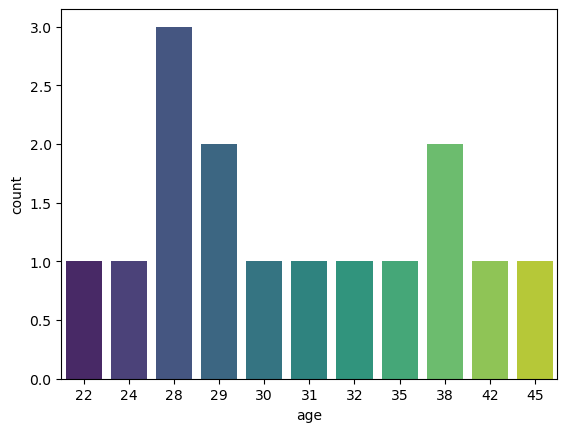

In [74]:
sns.countplot(data=df, x='age', palette='viridis')

Text(0.5, 1.0, 'Customer Count by Age Group')

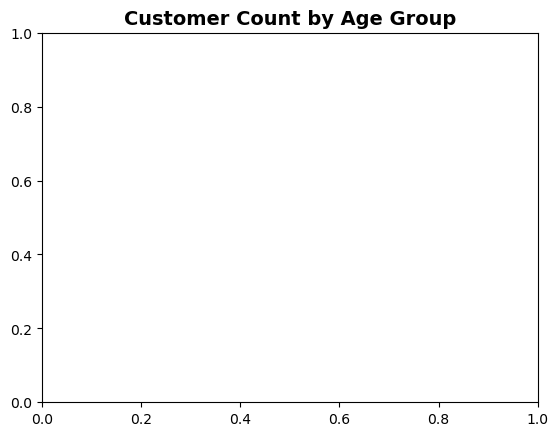

In [75]:
plt.title("Customer Count by Age Group", fontsize=14, fontweight='bold')

C:\Users\Bhagyashri\AppData\Local\Temp\ipykernel_2768\1280745417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', palette='viridis')


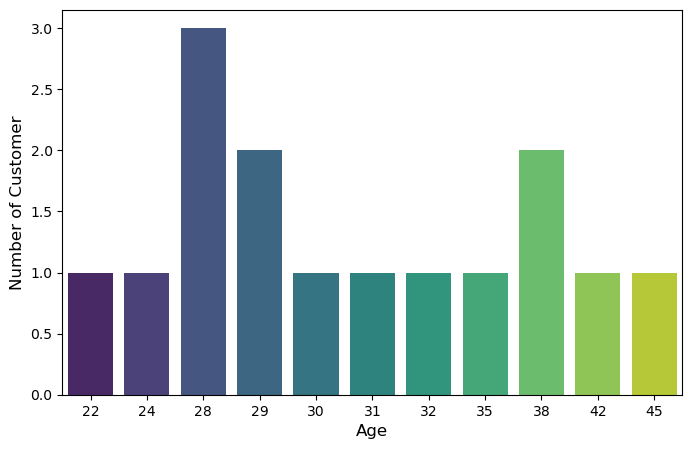

In [80]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='age', palette='viridis')
plt.xlabel("Age",fontsize=12)
plt.ylabel("Number of Customer",fontsize=12)
plt.show()

In [81]:
#visualisation task2 "Fantastic job on the first graph, Bhagyashri! Now, let's create our second visualization. The finance team wants to see if older customers tend to spend more. Please plot a Scatter Plot to show the relationship between 'age' on the X-axis and 'total_spend' on the Y-axis."

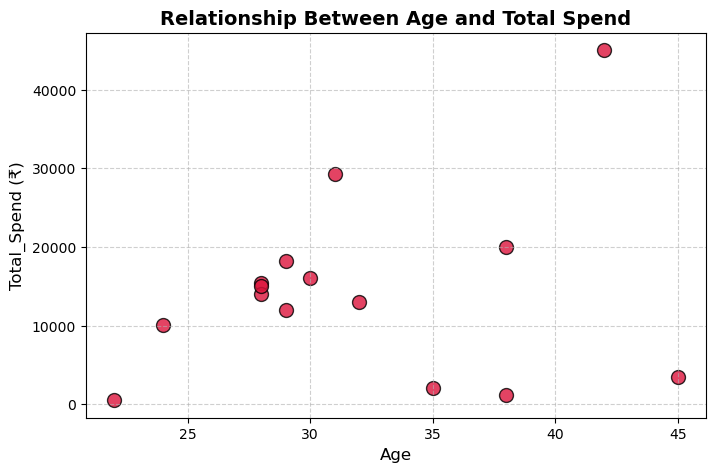

In [85]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'],df['total_spend'], color= 'crimson',s =100, alpha= 0.8, edgecolors='black')
plt.title("Relationship Between Age and Total Spend", fontsize=14, fontweight='bold')
plt.xlabel("Age",fontsize=12)
plt.ylabel("Total_Spend (₹)",fontsize=12)
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

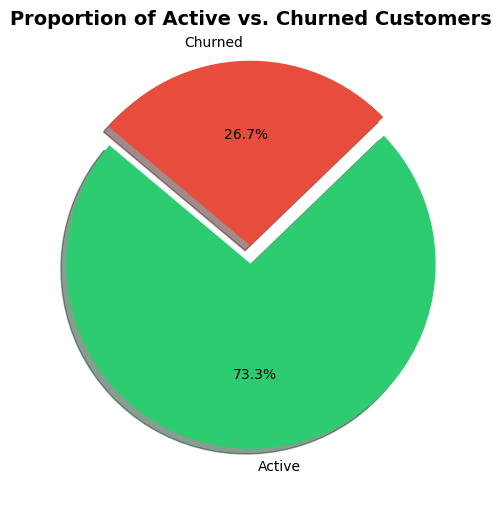

In [86]:
status_counts = df['churn_status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, 
        labels=status_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#2ecc71', '#e74c3c'], 
        explode=[0, 0.1], 
        shadow=True)
plt.title("Proportion of Active vs. Churned Customers", fontsize=14, fontweight='bold')
plt.show()

Project Overview & Key Business Insights

I have successfully completed an end-to-end Customer Churn & Retention Analysis project using SQL (SQLite) for data querying and Python (Matplotlib & Seaborn) for data visualization.

Here are the key takeaways and data-driven insights derived from the analysis:

Overall Churn Rate (Pie Chart Analysis):

73.3% of our customer base is currently Active, while 26.7% has Churned. This highlights a significant retention opportunity for the business to win back roughly a quarter of its user base.

Demographic Patterns (Scatter Plot Analysis):

There is a high density of purchasing activity among customers aged between 28 and 32 years.

This specific age bracket contributes most consistently to the company's revenue, with their total spending concentrated primarily between ₹10,000 and ₹30,000.

Strategic Recommendations:

Targeted Marketing: The marketing team should design tailored loyalty campaigns specifically for the 28–32 age demographic to maximize lifetime value (LTV).

Proactive Retention: Since the churn rate stands at 26.7%, executing a re-engagement strategy or feedback survey for churned accounts is highly recommended to improve the retention pipeline.

Technical Skills Demonstrated:

SQL Operators: BETWEEN, LIKE, IN, NOT IN for complex filtering.

Data Visualization: Count Plots (Bar Charts), Scatter Plots, and Pie Charts.

Libraries: Pandas, Matplotlib, Seaborn.